In [ ]:
%pip -q uninstall -y opencv-python opencv-python-headless opencv-contrib-python
%pip -q install opencv-contrib-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.1/82.1 MB 9.4 MB/s eta 0:00:00


In [ ]:
import os, sys, subprocess

REPO_DIR = 'imagefusion-rfn-nest'
if not os.path.isdir(REPO_DIR):
    subprocess.run(['git', 'clone', 'https://github.com/hli1221/imagefusion-rfn-nest.git'], check=True)
sys.path.insert(0, os.path.abspath(REPO_DIR))
print(sorted(os.listdir(REPO_DIR)))

['.git', '.idea', 'README.md', '__pycache__', 'analysis_matlab', 'args_fusion.py', 'framework', 'images', 'models', 'net.py', 'outputs', 'pytorch_msssim', 'test_21pairs.py', 'test_40pairs.py', 'train_fusionnet.py', 'utils.py']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
vtuav_zip_path = "/content/drive/MyDrive/test_ST_001.zip"
import gdown, os
os.makedirs('/content/vtuav', exist_ok=True)
!unzip -q {vtuav_zip_path} -d /content/vtuav

In [ ]:
VTUAV_ROOT = '/content/vtuav'   # folder with one sub-folder per sequence
SEQUENCES = None          # list of names, or None -> first MAX_SEQUENCES
MAX_SEQUENCES = 3
MAX_FRAMES = 300
SCALE = 0.5               # frames are 1920x1080; resize before fusion and tracking
TRACKER = 'CSRT'          # any OpenCV tracker: CSRT, KCF, MIL, ...

FS_TYPE = 'res'           # 'res' = learned RFN; 'add','avg','max','spa','nuclear' = fixed
ALPHA, W_IR, W_VI = 700, 6.0, 3.0     # defaults from the repo's test_21pairs.py
NEST_CKPT = None          # None -> path from the repo's args_fusion.py
RFN_CKPT = None
NORMALIZE_PER_FRAME = True   # repo min-max normalizes each output; can flicker

CACHE_DIR = 'fused_cache'
RESULTS_DIR = 'results'
PX_THRESHOLD = 20

In [ ]:
import re, time
from dataclasses import dataclass
import numpy as np, cv2, pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

IMG_EXT = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')
RGB_DIRS = ('rgb', 'visible', 'vis', 'vi', 'color')
IR_DIRS = ('ir', 'thermal', 'infrared', 't')
RGB_GT = ('rgb.txt', 'rgb_gt.txt', 'groundtruth_rgb.txt', 'groundtruth.txt')
IR_GT = ('ir.txt', 'ir_gt.txt', 'groundtruth_ir.txt', 'thermal.txt')

def list_frames(folder):
    return sorted(os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith(IMG_EXT))

def find_dir(d, names):
    for n in sorted(os.listdir(d)):
        p = os.path.join(d, n)
        if os.path.isdir(p) and n.lower() in names:
            return p

def find_file(d, names):
    for n in sorted(os.listdir(d)):
        if n.lower() in names and os.path.isfile(os.path.join(d, n)):
            return os.path.join(d, n)

def read_boxes(path):
    rows = []
    with open(path) as fh:
        for line in fh:
            vals = []
            for p in line.replace(',', ' ').replace(';', ' ').split()[:4]:
                try: vals.append(float(p))
                except ValueError: vals.append(np.nan)
            while len(vals) < 4: vals.append(np.nan)
            rows.append(vals)
    return np.array(rows, dtype=np.float64)

@dataclass
class Sequence:
    name: str
    rgb_files: list
    ir_files: list
    gts: list
    n: int

def load_sequence(seq_dir):
    rgb_dir, ir_dir = find_dir(seq_dir, RGB_DIRS), find_dir(seq_dir, IR_DIRS)
    if rgb_dir is None or ir_dir is None:
        raise FileNotFoundError('No RGB/thermal folders in %s: %s' % (seq_dir, os.listdir(seq_dir)))
    rgb_files, ir_files = list_frames(rgb_dir), list_frames(ir_dir)
    gt_paths = [p for p in (find_file(seq_dir, RGB_GT), find_file(seq_dir, IR_GT)) if p]
    if not gt_paths:
        raise FileNotFoundError('No ground-truth txt in %s: %s' % (seq_dir, os.listdir(seq_dir)))
    gts = [read_boxes(p) for p in gt_paths]
    n = min([len(rgb_files), len(ir_files)] + [len(g) for g in gts])
    return Sequence(os.path.basename(seq_dir.rstrip('/')), rgb_files, ir_files, gts, n)

def discover_sequences(root):
    return [n for n in sorted(os.listdir(root))
            if os.path.isdir(os.path.join(root, n))
            and find_dir(os.path.join(root, n), RGB_DIRS) and find_dir(os.path.join(root, n), IR_DIRS)]

In [ ]:
all_seqs = discover_sequences(VTUAV_ROOT)
print(len(all_seqs), 'sequences found under', VTUAV_ROOT)
if not all_seqs:
    print('Contents:', sorted(os.listdir(VTUAV_ROOT))[:20])   # zips may nest an extra folder

sequences = []
for nm in (SEQUENCES or all_seqs[:MAX_SEQUENCES]):
    s = load_sequence(os.path.join(VTUAV_ROOT, nm))
    sequences.append(s)
    print(s.name, '| frames:', s.n, '| gt files:', len(s.gts))
print(sequences[0].gts[0][:3])

11 sequences found under /content/vtuav
animal_001 | frames: 205 | gt files: 2
bike_003 | frames: 71 | gt files: 2
bike_005 | frames: 359 | gt files: 2
[[947. 551.  26.  32.]
 [947. 549.  24.  35.]
 [945. 550.  23.  34.]]


In [ ]:
!find /content/imagefusion-rfn-nest/models | head -50
!du -sh /content/imagefusion-rfn-nest/models
!grep -n "resume_nestfuse\|fusion_model" /content/imagefusion-rfn-nest/args_fusion.py

/content/imagefusion-rfn-nest/models
/content/imagefusion-rfn-nest/models/rfn_twostage.zip
/content/imagefusion-rfn-nest/models/nestfuse.zip
27M	/content/imagefusion-rfn-nest/models
13:	save_fusion_model = "models/train/fusionnet/"
16:	# save_fusion_model_noshort = "models/train/fusionnet_noshort/"
19:	# save_fusion_model_onestage = "models/train/fusionnet_onestage/"
28:	resume_fusion_model = None
30:	resume_nestfuse = './models/nestfuse/nestfuse_gray_1e2.model'
31:	# resume_nestfuse = None
33:	# fusion_model = "./models/fusionnet/3_Final_epoch_4_resConv_1e4ssimVI_feaAdd0123_05vi_35ir.model"
34:	# fusion_model = "./models/fusionnet/3_Final_epoch_4_resConv_1e4ssimVI_feaAdd0123_05vi_35ir_nodense_in_decoder.model"
35:	fusion_model = './models/rfn_twostage/'


In [ ]:
!cd /content/imagefusion-rfn-nest/models && unzip -q -o nestfuse.zip && unzip -q -o rfn_twostage.zip
!find /content/imagefusion-rfn-nest/models -name "*.model" | sort

/content/imagefusion-rfn-nest/models/nestfuse/nestfuse_gray_1e2.model
/content/imagefusion-rfn-nest/models/rfn_twostage/6.0/Final_epoch_2_alpha_700_wir_6.0_wvi_3.0_ssim_vi.model


In [ ]:
import torch
import torch.nn.functional as F

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

_argv = sys.argv; sys.argv = [sys.argv[0]]      # args_fusion parses argv at import
try:
    from args_fusion import args as rfn_args
finally:
    sys.argv = _argv
from net import NestFuse_light2_nodense, Fusion_network

def resolve(p):
    for q in (p, os.path.join(REPO_DIR, p)):
        if os.path.exists(q): return q
    raise FileNotFoundError('Checkpoint not found: %s. Set NEST_CKPT / RFN_CKPT.' % p)

nest_ckpt = resolve(NEST_CKPT or rfn_args.resume_nestfuse)
default_rfn = os.path.join(rfn_args.fusion_model, str(W_IR),
                           'Final_epoch_2_alpha_%s_wir_%s_wvi_%s_ssim_vi.model' % (ALPHA, W_IR, W_VI))
rfn_ckpt = resolve(RFN_CKPT or default_rfn)
print(nest_ckpt, rfn_ckpt, sep='\n')

NB_FILTER = [64, 112, 160, 208, 256]
nest_model = NestFuse_light2_nodense(NB_FILTER, 1, 1, deepsupervision=False)
nest_model.load_state_dict(torch.load(nest_ckpt, map_location='cpu'))
fusion_model = Fusion_network(NB_FILTER, FS_TYPE)
fusion_model.load_state_dict(torch.load(rfn_ckpt, map_location='cpu'))
nest_model.eval().to(DEVICE); fusion_model.eval().to(DEVICE)

device: cuda
imagefusion-rfn-nest/./models/nestfuse/nestfuse_gray_1e2.model
imagefusion-rfn-nest/./models/rfn_twostage/6.0/Final_epoch_2_alpha_700_wir_6.0_wvi_3.0_ssim_vi.model


/content/imagefusion-rfn-nest/net.py:35: SyntaxWarning: "is" with 'float' literal. Did you mean "=="?
  if lef_right%2 is 0.0:
/content/imagefusion-rfn-nest/net.py:44: SyntaxWarning: "is" with 'float' literal. Did you mean "=="?
  if top_bot%2 is 0.0:
/content/imagefusion-rfn-nest/net.py:193: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  if spatial_type is 'mean':
/content/imagefusion-rfn-nest/net.py:195: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  elif spatial_type is 'sum':
/content/imagefusion-rfn-nest/net.py:242: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  if self.fs_type is 'add':
/content/imagefusion-rfn-nest/net.py:244: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  elif self.fs_type is 'avg':
/content/imagefusion-rfn-nest/net.py:246: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  elif self.fs_type is 'max':
/content/imagefusion-rfn-nest/net.py:248: SyntaxWarning: "is" with 'str' literal. Did you mean "

Fusion_network(
  (fusion_block1): FusionBlock_res(
    (conv_fusion): ConvLayer(
      (reflection_pad): ReflectionPad2d((1, 1, 1, 1))
      (conv2d): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1))
      (dropout): Dropout2d(p=0.5, inplace=False)
    )
    (conv_ir): ConvLayer(
      (reflection_pad): ReflectionPad2d((1, 1, 1, 1))
      (conv2d): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
      (dropout): Dropout2d(p=0.5, inplace=False)
    )
    (conv_vi): ConvLayer(
      (reflection_pad): ReflectionPad2d((1, 1, 1, 1))
      (conv2d): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
      (dropout): Dropout2d(p=0.5, inplace=False)
    )
    (bottelblock): Sequential(
      (0): ConvLayer(
        (reflection_pad): ReflectionPad2d((0, 0, 0, 0))
        (conv2d): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1))
        (dropout): Dropout2d(p=0.5, inplace=False)
      )
      (1): ConvLayer(
        (reflection_pad): ReflectionPad2d((1, 1, 1, 1))
        (conv2d): Conv2d(

In [ ]:
def _fuse_tensor(ir, vi):
    h, w = ir.shape[-2:]
    ph, pw = (-h) % 16, (-w) % 16
    if ph or pw:
        ir = F.pad(ir, (0, pw, 0, ph), mode='reflect')
        vi = F.pad(vi, (0, pw, 0, ph), mode='reflect')
    fused = fusion_model(nest_model.encoder(ir), nest_model.encoder(vi))
    return nest_model.decoder_eval(fused)[0][..., :h, :w]

@torch.no_grad()
def fuse_pair(vis_gray, ir_gray, base=512):
    h, w = vis_gray.shape
    vi = torch.from_numpy(vis_gray.astype(np.float32))[None, None].to(DEVICE)
    ir = torch.from_numpy(ir_gray.astype(np.float32))[None, None].to(DEVICE)
    if h <= base and w <= base:
        out = _fuse_tensor(ir, vi)
    else:
        hc, wc = h // 2, w // 2
        tiles = [(0, hc+3, 0, wc+3), (0, hc+3, wc-2, w), (hc-2, h, 0, wc+3), (hc-2, h, wc-2, w)]
        acc = torch.zeros(1, 1, h, w, device=DEVICE); cnt = torch.zeros_like(acc)
        for y0, y1, x0, x1 in tiles:
            acc[..., y0:y1, x0:x1] += _fuse_tensor(ir[..., y0:y1, x0:x1], vi[..., y0:y1, x0:x1])
            cnt[..., y0:y1, x0:x1] += 1
        out = acc / cnt
    out = out[0, 0].float().cpu().numpy()
    if NORMALIZE_PER_FRAME:
        out = (out - out.min()) / (out.max() - out.min() + 1e-5) * 255
    return np.clip(out, 0, 255).astype(np.uint8)

def rescale(img):
    return img if SCALE == 1 else cv2.resize(img, None, fx=SCALE, fy=SCALE, interpolation=cv2.INTER_AREA)

def read_pair(seq, i):
    rgb = cv2.imread(seq.rgb_files[i], cv2.IMREAD_COLOR)
    ir = cv2.imread(seq.ir_files[i], cv2.IMREAD_GRAYSCALE)
    if ir.shape[:2] != rgb.shape[:2]:
        ir = cv2.resize(ir, (rgb.shape[1], rgb.shape[0]))
    return rgb, ir

CACHE_TAG = os.path.join(CACHE_DIR, 's%s_%s_a%s_w%s-%s_n%d' % (SCALE, FS_TYPE, ALPHA, W_IR, W_VI, int(NORMALIZE_PER_FRAME)))
fusion_stats = {'sec': 0.0, 'n': 0}

def get_frame(seq, i, method):          # method: 'rgb' | 'thermal' | 'fused'; returns BGR uint8
    if method == 'fused':
        path = os.path.join(CACHE_TAG, seq.name, '%06d.png' % i)
        if os.path.exists(path):
            return cv2.imread(path, cv2.IMREAD_COLOR)
        rgb, ir = read_pair(seq, i)
        t0 = time.time()
        g = fuse_pair(rescale(cv2.cvtColor(rgb, cv2.COLOR_BGR2GRAY)), rescale(ir))
        fusion_stats['sec'] += time.time() - t0; fusion_stats['n'] += 1
        os.makedirs(os.path.dirname(path), exist_ok=True)
        cv2.imwrite(path, g)
        return cv2.cvtColor(g, cv2.COLOR_GRAY2BGR)
    rgb, ir = read_pair(seq, i)
    return rescale(rgb) if method == 'rgb' else cv2.cvtColor(rescale(ir), cv2.COLOR_GRAY2BGR)

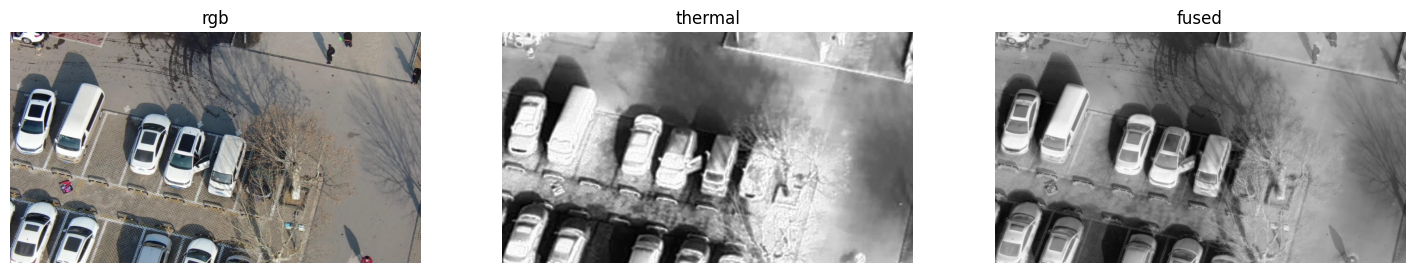

In [ ]:
seq = sequences[0]; i = min(10, seq.n - 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, m in zip(axes, ['rgb', 'thermal', 'fused']):
    ax.imshow(cv2.cvtColor(get_frame(seq, i, m), cv2.COLOR_BGR2RGB)); ax.set_title(m); ax.axis('off')
plt.show()

In [ ]:
def make_tracker(name):
    ctor = 'Tracker%s_create' % name
    for mod in (cv2, getattr(cv2, 'legacy', None)):
        if mod is not None and hasattr(mod, ctor):
            return getattr(mod, ctor)()
    raise RuntimeError('Tracker %s unavailable (need opencv-contrib-python)' % name)

def valid_box(b):
    return bool(np.isfinite(b).all() and b[2] > 0 and b[3] > 0)

def track_sequence(seq, method, n):
    init_gt = seq.gts[0][0]
    if not valid_box(init_gt):
        return None, 0.0
    boxes = np.full((n, 4), np.nan); boxes[0] = init_gt
    x, y, w, h = [int(round(v * SCALE)) for v in init_gt]
    tracker = make_tracker(TRACKER)
    tracker.init(get_frame(seq, 0, method), (x, y, max(w, 1), max(h, 1)))
    last, sec = boxes[0].copy(), 0.0
    for i in range(1, n):
        frame = get_frame(seq, i, method)
        t0 = time.time(); ok, box = tracker.update(frame); sec += time.time() - t0
        if ok:
            last = np.array(box, dtype=np.float64) / SCALE
        boxes[i] = last
    return boxes, sec

def box_iou(a, b):
    iw = np.clip(np.minimum(a[:,0]+a[:,2], b[:,0]+b[:,2]) - np.maximum(a[:,0], b[:,0]), 0, None)
    ih = np.clip(np.minimum(a[:,1]+a[:,3], b[:,1]+b[:,3]) - np.maximum(a[:,1], b[:,1]), 0, None)
    inter = iw * ih
    return inter / np.maximum(a[:,2]*a[:,3] + b[:,2]*b[:,3] - inter, 1e-9)

def center_err(a, b):
    ca = np.stack([a[:,0]+a[:,2]/2, a[:,1]+a[:,3]/2], 1)
    cb = np.stack([b[:,0]+b[:,2]/2, b[:,1]+b[:,3]/2], 1)
    return np.linalg.norm(ca - cb, axis=1)

THRESHOLDS = np.linspace(0, 1, 21)

def evaluate(pred, gts):
    n = len(pred)
    best_iou, best_err, valid = np.zeros(n), np.full(n, np.inf), np.zeros(n, bool)
    for g in gts:                        # RGB and thermal GT: keep whichever scores better
        g = g[:n]
        v = np.isfinite(g).all(1) & (g[:,2] > 0) & (g[:,3] > 0)
        p, gg = np.nan_to_num(pred), np.nan_to_num(g)
        best_iou = np.maximum(best_iou, np.where(v, box_iou(p, gg), 0.0))
        best_err = np.minimum(best_err, np.where(v, center_err(p, gg), np.inf))
        valid |= v
    if not valid.any():
        return None
    curve = np.array([(best_iou[valid] > t).mean() for t in THRESHOLDS])
    return {'curve': curve, 'MSR': curve.mean(), 'MPR': (best_err[valid] <= PX_THRESHOLD).mean(), 'frames': int(valid.sum())}

In [ ]:
STRIDE = None   # None = infer per sequence from number of images / number of annotations

for s in sequences:
    s.n = min(len(s.rgb_files), len(s.ir_files))          # image frames
    s.stride = STRIDE or max(1, round(s.n / len(s.gts[0])))
    print(s.name, '| images:', s.n, '| annotations:', len(s.gts[0]), '| stride:', s.stride)

animal_001 | images: 2047 | annotations: 205 | stride: 10
bike_003 | images: 704 | annotations: 71 | stride: 10
bike_005 | images: 3583 | annotations: 359 | stride: 10


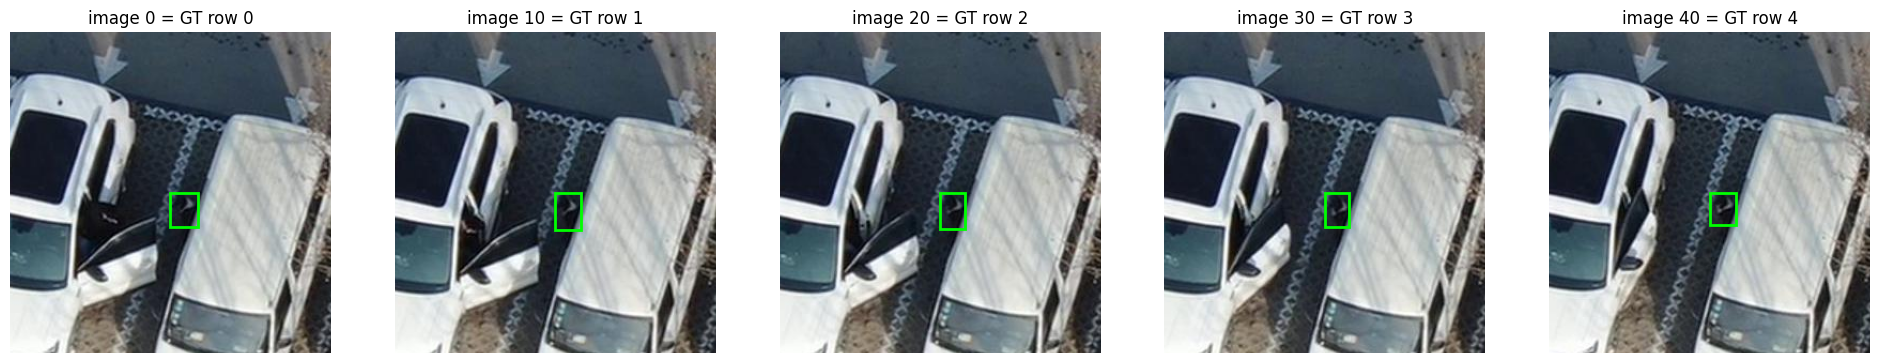

In [ ]:
seq = sequences[0]
fig, axes = plt.subplots(1, 5, figsize=(24, 5))
for ax, k in zip(axes, [0, 1, 2, 3, 4]):
    i = k * seq.stride
    ax.imshow(cv2.cvtColor(read_pair(seq, i)[0], cv2.COLOR_BGR2RGB))
    x, y, w, h = seq.gts[0][k]
    ax.add_patch(plt.Rectangle((x, y), w, h, fill=False, edgecolor='lime', linewidth=2))
    ax.set_xlim(x - 150, x + 150); ax.set_ylim(y + 150, y - 150)
    ax.set_title('image %d = GT row %d' % (i, k)); ax.axis('off')
plt.show()

In [ ]:
# METHODS = ['rgb', 'thermal', 'fused']
# preds, scores, track_time = {}, {}, {m: [0.0, 0] for m in METHODS}

# for seq in sequences:
#     n = min(seq.n, MAX_FRAMES)
#     for m in METHODS:
#         boxes, sec = track_sequence(seq, m, n)
#         if boxes is None:
#             print('skipping', seq.name, '- no valid first-frame box'); break
#         res = evaluate(boxes, seq.gts)
#         preds[(m, seq.name)], scores[(m, seq.name)] = boxes, res
#         track_time[m][0] += sec; track_time[m][1] += n - 1
#         if res:
#             print('%-12s %-8s MSR=%.3f MPR=%.3f (%d frames)' % (seq.name, m, res['MSR'], res['MPR'], res['frames']))

# if fusion_stats['n']:
#     print('RFN-Nest: %.2f frames/s on %s' % (fusion_stats['n'] / fusion_stats['sec'], DEVICE))

In [ ]:
METHODS = ['rgb', 'thermal', 'fused']
preds, scores, track_time = {}, {}, {m: [0.0, 0] for m in METHODS}

for seq in sequences:
    n = min(seq.n, MAX_FRAMES)                        # MAX_FRAMES now counts image frames
    for m in METHODS:
        boxes, sec = track_sequence(seq, m, n)
        if boxes is None:
            print('skipping', seq.name, '- no valid first-frame box'); break
        sampled = boxes[::seq.stride]                 # predictions at the annotated frames
        res = evaluate(sampled, seq.gts)
        preds[(m, seq.name)], scores[(m, seq.name)] = boxes, res
        track_time[m][0] += sec; track_time[m][1] += n - 1
        if res:
            print('%-12s %-8s MSR=%.3f MPR=%.3f (%d scored frames)' % (seq.name, m, res['MSR'], res['MPR'], res['frames']))
    else:
        st = evaluate(np.tile(seq.gts[0][0], (len(boxes[::seq.stride]), 1)), seq.gts)
        print('%-12s %-8s MSR=%.3f MPR=%.3f' % (seq.name, 'static', st['MSR'], st['MPR']))

if fusion_stats['n']:
    print('RFN-Nest: %.2f frames/s on %s' % (fusion_stats['n'] / fusion_stats['sec'], DEVICE))

animal_001   rgb      MSR=0.602 MPR=1.000 (30 scored frames)
animal_001   thermal  MSR=0.603 MPR=1.000 (30 scored frames)
animal_001   fused    MSR=0.057 MPR=0.067 (30 scored frames)
animal_001   static   MSR=0.122 MPR=0.200
bike_003     rgb      MSR=0.638 MPR=0.900 (30 scored frames)
bike_003     thermal  MSR=0.627 MPR=0.700 (30 scored frames)
bike_003     fused    MSR=0.343 MPR=0.500 (30 scored frames)
bike_003     static   MSR=0.097 MPR=0.033
bike_005     rgb      MSR=0.638 MPR=1.000 (30 scored frames)
bike_005     thermal  MSR=0.676 MPR=1.000 (30 scored frames)
bike_005     fused    MSR=0.633 MPR=0.967 (30 scored frames)
bike_005     static   MSR=0.221 MPR=0.033
RFN-Nest: 0.51 frames/s on cuda


,MSR,MPR,sequences,tracker_fps
input,,,,
rgb,0.626,0.967,3,16.000
thermal,0.635,0.900,3,17.765
fused,0.344,0.511,3,16.383


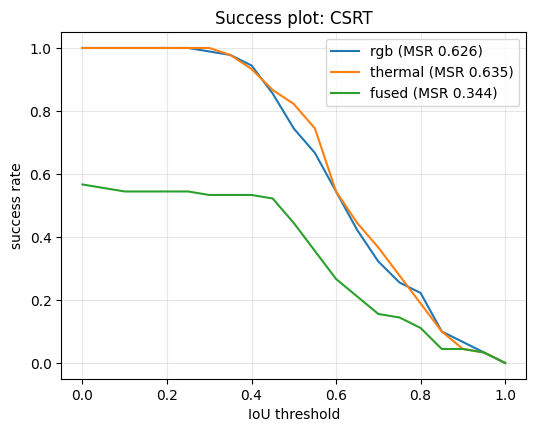

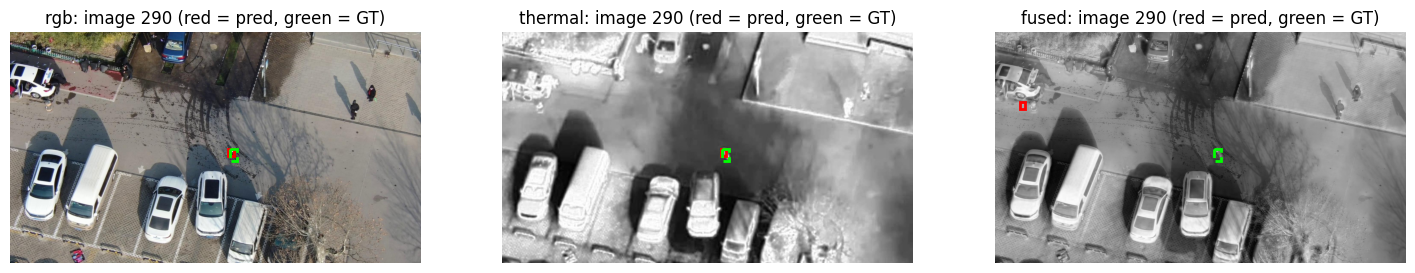

In [ ]:
rows = []
for m in METHODS:
    per_seq = [scores[(m, s.name)] for s in sequences if scores.get((m, s.name))]
    if per_seq:
        sec, cnt = track_time[m]
        rows.append({'input': m, 'MSR': np.mean([r['MSR'] for r in per_seq]),
                     'MPR': np.mean([r['MPR'] for r in per_seq]),
                     'sequences': len(per_seq), 'tracker_fps': cnt / max(sec, 1e-9)})
table = pd.DataFrame(rows).set_index('input')
display(table.round(3))

plt.figure(figsize=(6, 4.5))
for m in table.index:
    per_seq = [scores[(m, s.name)] for s in sequences if scores.get((m, s.name))]
    plt.plot(THRESHOLDS, np.mean([r['curve'] for r in per_seq], 0), label='%s (MSR %.3f)' % (m, table.loc[m, 'MSR']))
plt.xlabel('IoU threshold'); plt.ylabel('success rate'); plt.title('Success plot: %s' % TRACKER)
plt.legend(); plt.grid(alpha=0.3); plt.show()

# seq = sequences[0]; i = min(seq.n, MAX_FRAMES) - 1
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# for ax, m in zip(axes, METHODS):
#     ax.imshow(cv2.cvtColor(get_frame(seq, i, m), cv2.COLOR_BGR2RGB))
#     if (m, seq.name) in preds:
#         px, py, pw, ph = preds[(m, seq.name)][i] * SCALE
#         ax.add_patch(plt.Rectangle((px, py), pw, ph, fill=False, edgecolor='red', linewidth=2))
#     gx, gy, gw, gh = seq.gts[0][i] * SCALE
#     if np.isfinite([gx, gy, gw, gh]).all():
#         ax.add_patch(plt.Rectangle((gx, gy), gw, gh, fill=False, edgecolor='lime', linewidth=2, linestyle='--'))
#     ax.set_title('%s, frame %d (red = pred, green = GT)' % (m, i)); ax.axis('off')
# plt.show()

seq = sequences[0]
k = (min(seq.n, MAX_FRAMES) - 1) // seq.stride        # last annotated frame inside the run
i = k * seq.stride
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, m in zip(axes, METHODS):
    ax.imshow(cv2.cvtColor(get_frame(seq, i, m), cv2.COLOR_BGR2RGB))
    if (m, seq.name) in preds:
        px, py, pw, ph = preds[(m, seq.name)][i] * SCALE
        ax.add_patch(plt.Rectangle((px, py), pw, ph, fill=False, edgecolor='red', linewidth=2))
    gx, gy, gw, gh = seq.gts[0][k] * SCALE
    if np.isfinite([gx, gy, gw, gh]).all():
        ax.add_patch(plt.Rectangle((gx, gy), gw, gh, fill=False, edgecolor='lime', linewidth=2, linestyle='--'))
    ax.set_title('%s: image %d (red = pred, green = GT)' % (m, i)); ax.axis('off')
plt.show()

In [ ]:
for (m, name), boxes in preds.items():
    os.makedirs(os.path.join(RESULTS_DIR, m), exist_ok=True)
    np.savetxt(os.path.join(RESULTS_DIR, m, name + '.txt'), boxes, fmt='%.2f', delimiter=',')
table.to_csv(os.path.join(RESULTS_DIR, 'summary.csv'))
print('saved to', os.path.abspath(RESULTS_DIR))

saved to /content/results


animal_001 {'rgb': np.float64(0.602), 'thermal': np.float64(0.603), 'fused': np.float64(0.057)}
bike_003 {'rgb': np.float64(0.638), 'thermal': np.float64(0.627), 'fused': np.float64(0.343)}
bike_005 {'rgb': np.float64(0.638), 'thermal': np.float64(0.676), 'fused': np.float64(0.633)}


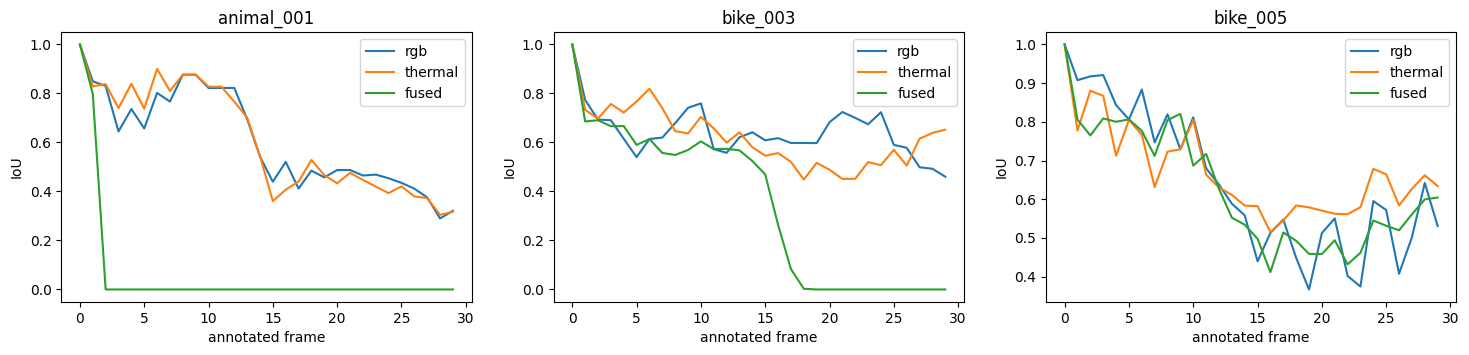

first zero-overlap frame (fused): {'animal_001': 2, 'bike_003': 19, 'bike_005': None}


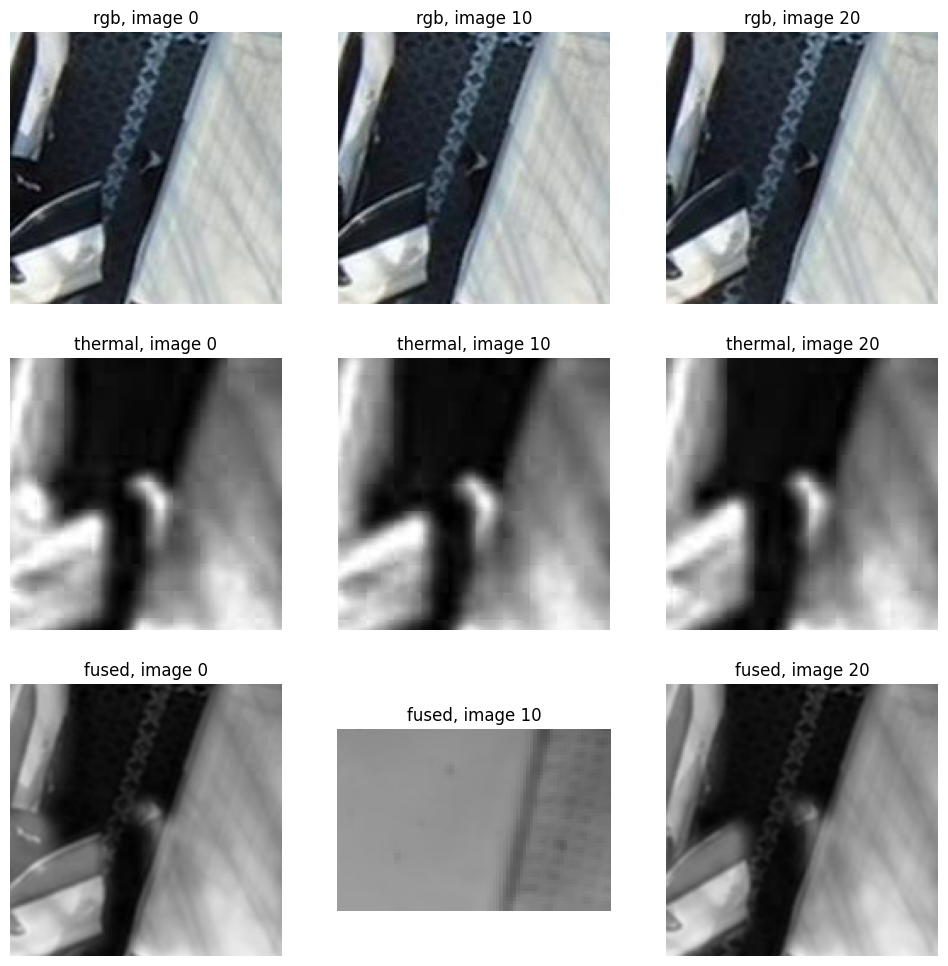

In [ ]:
for seq in sequences:
    print(seq.name, {m: round(scores[(m, seq.name)]['MSR'], 3) for m in METHODS if scores.get((m, seq.name))})

fig, axes = plt.subplots(1, len(sequences), figsize=(6 * len(sequences), 3.5), squeeze=False)
lost = {}
for ax, seq in zip(axes[0], sequences):
    for m in METHODS:
        p = preds[(m, seq.name)][::seq.stride]
        g = seq.gts[0][:len(p)]
        iou = box_iou(np.nan_to_num(p), np.nan_to_num(g))
        ax.plot(iou, label=m)
        if m == 'fused':
            z = np.where(iou == 0)[0]
            lost[seq.name] = int(z[0]) if len(z) else None
    ax.set_title(seq.name); ax.set_xlabel('annotated frame'); ax.set_ylabel('IoU'); ax.legend()
plt.show()
print('first zero-overlap frame (fused):', lost)

seq = next((s for s in sequences if lost.get(s.name)), None)
if seq:
    k = lost[seq.name]
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    for c, kk in enumerate([max(k - 5, 0), max(k - 1, 0), k]):
        i = kk * seq.stride
        x, y, w, h = seq.gts[0][kk]
        cx, cy = int(x + w / 2), int(y + h / 2)
        for r, m in enumerate(['rgb', 'thermal', 'fused']):
            f = get_frame(seq, i, m)
            s = int(SCALE * 80)
            sx, sy = int(cx * SCALE), int(cy * SCALE)
            axes[r, c].imshow(cv2.cvtColor(f[max(sy - s, 0):sy + s, max(sx - s, 0):sx + s], cv2.COLOR_BGR2RGB))
            axes[r, c].set_title('%s, image %d' % (m, i)); axes[r, c].axis('off')
    plt.show()

In [ ]:
#download results
!zip -r /content/results_1.zip /content/results/

  adding: content/results/ (stored 0%)
  adding: content/results/fused/ (stored 0%)
  adding: content/results/fused/bike_003.txt (deflated 83%)
  adding: content/results/fused/animal_001.txt (deflated 87%)
  adding: content/results/fused/bike_005.txt (deflated 85%)
  adding: content/results/thermal/ (stored 0%)
  adding: content/results/thermal/bike_003.txt (deflated 83%)
  adding: content/results/thermal/animal_001.txt (deflated 88%)
  adding: content/results/thermal/bike_005.txt (deflated 84%)
  adding: content/results/summary.csv (deflated 37%)
  adding: content/results/rgb/ (stored 0%)
  adding: content/results/rgb/bike_003.txt (deflated 81%)
  adding: content/results/rgb/animal_001.txt (deflated 88%)
  adding: content/results/rgb/bike_005.txt (deflated 84%)


In [ ]:
from google.colab import files
files.download("/content/results_1.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>